In [12]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [13]:
from openai import OpenAI

In [ ]:
# openai = OpenAI(base_url="https://openrouter.ai/api/v1",api_key=os.getenv('OPENROUTER_API_KEY'))


In [ ]:
# result = openai.chat.completions.create(
#     messages=[{'role': 'user', 'content': 'generate an artistic image for london'}],
#     model='openai/gpt-5-image-mini',
#     extra_body={
#         "modalities": ["image", "text"],
#     }
# )



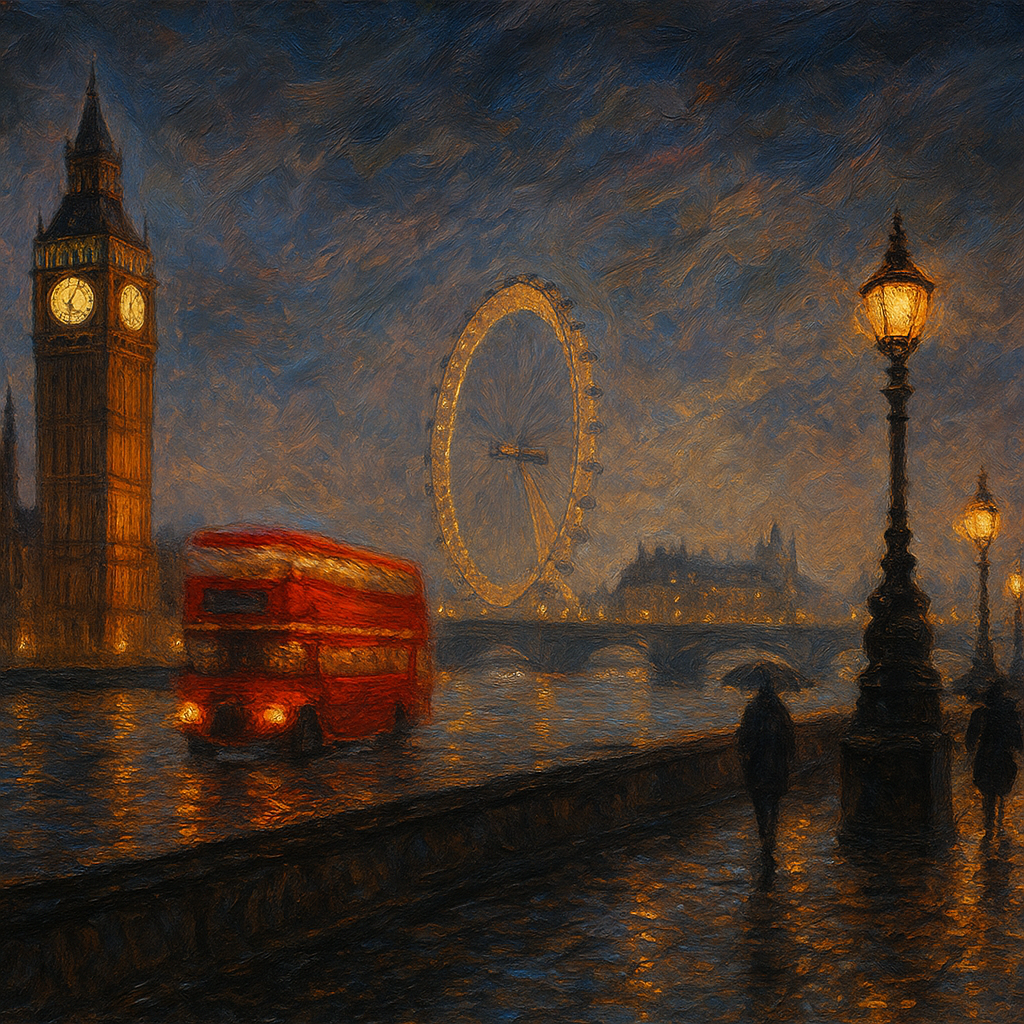

In [ ]:
# print(result.choices[0].message.images[0]['image_url']['url'])

{'url': ''}
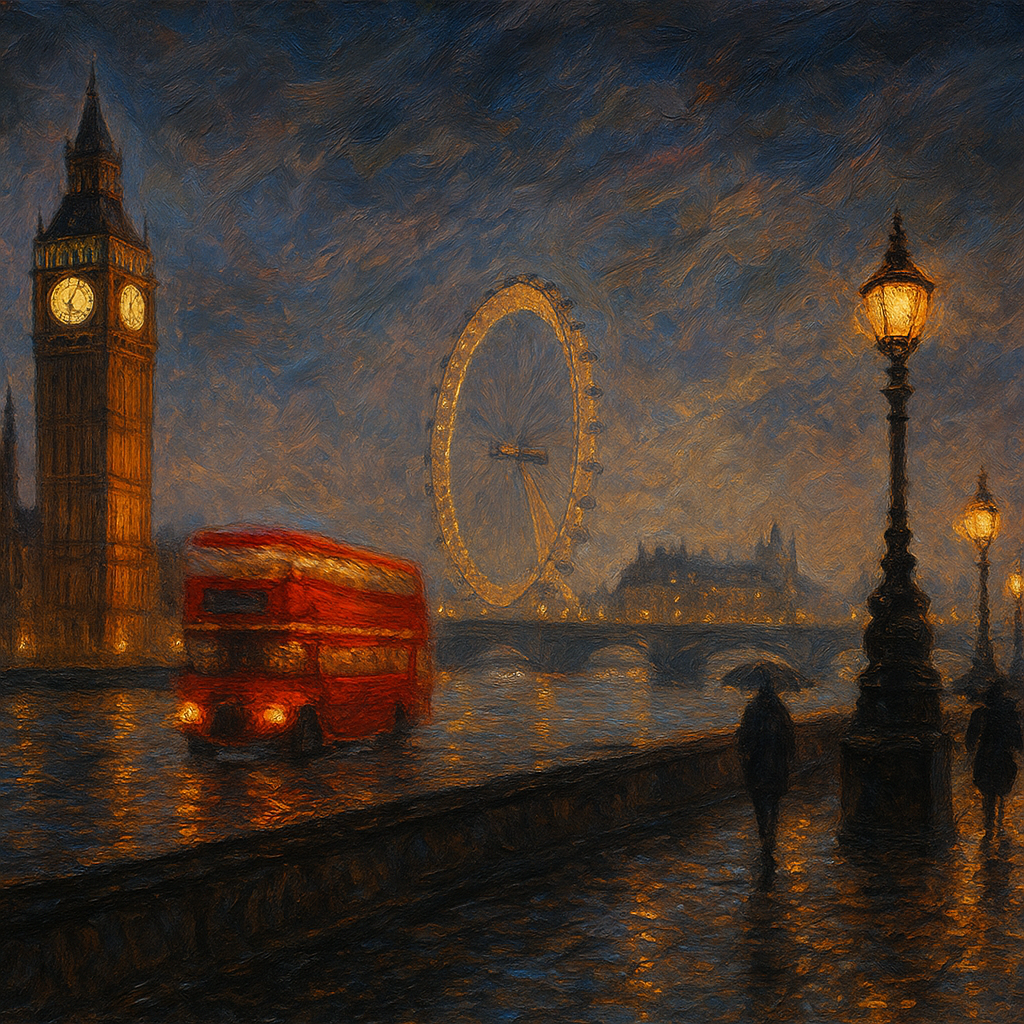

In [ ]:
# result.choices[0].message.images[0]['image_url']

In [ ]:
# # for block in result.choices[0].message.images:
# #     if block.type == "text":
# #         print(block.text)
# if result.choices[0].message.images == "image_url":
#         # base64 data URL — decode and save
#     import base64
#     img_data = result.choices[0].message.images[0].image_url.url.split(",")[1]
#     with open("london.png", "wb") as f:
#         f.write(base64.b64decode(img_data))
    

In [ ]:
import requests
import base64

response = requests.post(
    "https://openrouter.ai/api/v1/chat/completions",
    headers={
        "Authorization": f"Bearer {os.getenv('OPENROUTER_API_KEY')}",
        "Content-Type": "application/json",
    },
    json={
        "model": "openai/gpt-5-image-mini",
        "messages": [{"role": "user", "content": "generate an artistic image for london"}],
        "modalities": ["image", "text"],
    },
    timeout=120,
)

result = response.json()
message = result['choices'][0]["message"]



{'role': 'assistant',
 'content': None,
 'refusal': None,
 'reasoning': '**Crafting an artistic prompt**\n\nI’m working on creating a prompt for an artistic image of London. I need to include specific elements like Big Ben, the London Eye, and other iconic landmarks, along with the mood of elegance and cinematic style. The color palette will feature muted blues and warm gold, set during sunset with a low angle. I’ll aim for a panoramic aspect ratio, possibly 3:2, and avoid copyrighted characters, focusing on the landscape and atmosphere.**Creating a vivid image prompt**\n\nI’m crafting a detailed prompt for an artistic image of London at dusk. In the foreground, I want to show the Thames reflecting lights, a red double-decker bus, and a classic black cab crossing Westminster Bridge. The midground features silhouettes of Westminster Palace and Big Ben, with the London Eye lit softly. The sky displays a dramatic sunset with warm golds and deep blues while including diverse pedestrians wi
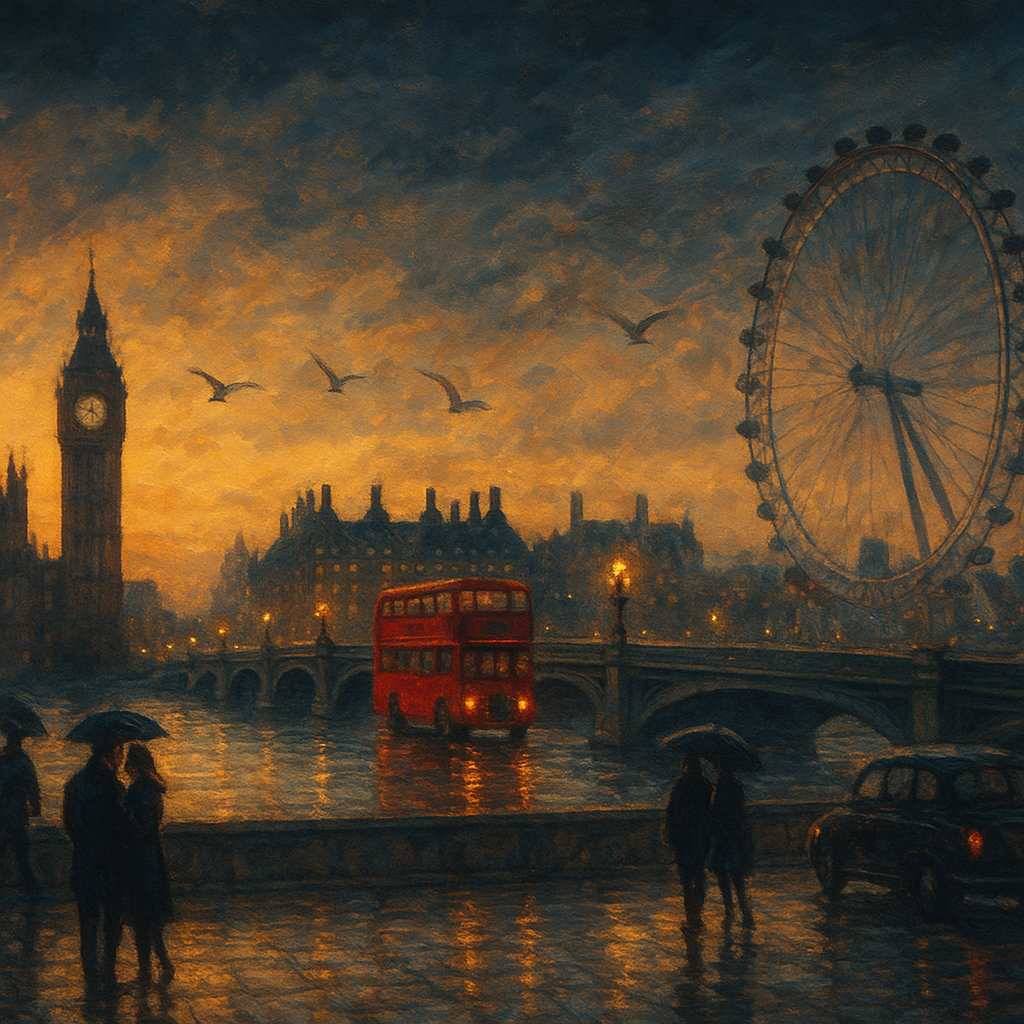

In [ ]:
message = result['choices'][0]["message"]
message

In [ ]:
# Text response (if any)
print("Text:", message.get("content"))

# Image is in message["images"], not message["content"]
images = message.get("images", [])
if images:
    img_url = images[0]["image_url"]["url"]       # data:image/png;base64,...
    b64_data = img_url.split(",")[1]
    with open("london.png", "wb") as f:
        f.write(base64.b64decode(b64_data))
    print("Image saved to london.png")
else:
    print("No image returned")

Text: None
Image saved to london.png
